The following code imports simulation data of a SIRS model and plotts diferent useful graphics for the model analysis. 

Importing the libraries: 

In [99]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.signal import find_peaks

# Activating LaTex for Matplotlib globaly:
plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}", 
})

Global Graphics configurations:

In [2]:
params = {
    'font.family': 'serif',       # Família da fonte. 'serif' (como Times New Roman) é comum para artigos.
                                  # Outras opções: 'sans-serif' (como Arial), 'monospace' (fonte de código).
    'font.size': 14,              # Tamanho base da fonte para os números nos eixos (ticks).
    
    'axes.titlesize': 18,         # Tamanho do título principal de cada gráfico.
    'axes.labelsize': 16,         # Tamanho dos rótulos dos eixos X e Y.
    
    'legend.fontsize': 14,        # Tamanho da fonte da legenda.
    
    # Você também pode definir outras propriedades padrão, se quiser
    'lines.linewidth': 2,         # Espessura padrão das linhas
    'axes.grid': True,            # Habilitar a grade por padrão
    'grid.linestyle': '--',       # Estilo da linha da grade
    'grid.alpha': 0.6             # Transparência da grade
}
plt.rcParams.update(params)

Importing the data in the h5py format and listing all the simulations:

In [49]:
arquivo_h5 = h5py.File('Mapas de Calor - N = 100000.0.h5', 'r')
simulacoes_disponiveis = list(arquivo_h5.keys()) # Cria uma lista com as chaves das simulações do arquivo
print(len(simulacoes_disponiveis))

6


Simulation Parameters:

In [15]:
def parameters(grupo_simulacao):
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    gamma = params.get('gamma', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', 'N/A')
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    print(f'r0 = {r0}, gamma = {gamma}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}', 't_pico = {t_pico}')

In [47]:
arquivo_h5 = h5py.File('Mapas de Calor - N = 100000.0.h5', 'r')
parameters(arquivo_h5['sim_0'])

r0 = 1.1, gamma = 0.1, a = 0.01, n = 100000.0, delta = 0.005, vac_num = 0.2, t0 = 80.0, Tempo até atingir o estado estacionário = 3000.0, Motivo da parada = t_total, Probabilidade de Extinção = 0.0 t_pico = {t_pico}


In [50]:
print(simulacoes_disponiveis)  # Exibe as simulações disponíveis

['sim_0', 'sim_1', 'sim_2', 'sim_3', 'sim_4', 'sim_5']


Ixt Graphic with vaccination Campaign:

In [7]:
def ixt(grupo_simulacao, nome_arquivo_saida=None):
    # 1. Extrai os dados e parâmetros dos datasets
    tempo = grupo_simulacao['tempo'][:]
    I = grupo_simulacao['I'][:]
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    gamma = params.get('gamma', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', tempo[-1])
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    t_pico = tempo[np.argmax(I)] if np.any(I) else None
    I_Steady = (delta/(delta + gamma))*(1 - 1/r0)
    plt.figure(figsize=(10, 6))
    # 2. Plotando os gráficos:
    plt.plot(tempo, I, label='Infected', color='blue')
    plt.plot(tempo, np.ones_like(tempo)*I_Steady, '--', color='black', label=r'I $(\infty)$')
    plt.axvspan(t0, tf, color='lightblue', alpha=0.7, label="Vaccination Campaign")
    plt.title('SIRS Model with vaccination - Infected time series')
    plt.grid()
    plt.yscale('log')
    plt.xlabel('Time (days)')
    plt.ylabel('Infected Ratio I(t)')
    plt.legend(loc = 'lower right')
    print(f'r0 = {r0}, gamma = {gamma}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}, t_pico = {t_pico}')

In [ ]:
arquivo_h5 = h5py.File('Vale Profundo.h5', 'r')
ixt(arquivo_h5['sim_0'])   # Exemplo de uso da função com a primeira simulação

KeyError: "Unable to synchronously open object (object 'tempo' doesn't exist)"

Gráficos de (S, I, R) x t com campanha de vacinação:

In [9]:
def sirxt(grupo_simulacao, nome_arquivo_saida=None):
    # 1. Extrai os dados e parâmetros dos datasets
    tempo = grupo_simulacao['tempo'][:]
    I = grupo_simulacao['I'][:]
    S = grupo_simulacao['S'][:]
    R = grupo_simulacao['R'][:]
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    mu = params.get('mu', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', tempo[-1])
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    # 2. Plotando os gráficos:
    plt.plot(tempo, I, label='Infectados', color='blue')
    plt.plot(tempo, S, label='Suscetíveis', color='red')
    plt.plot(tempo, R, label='Recuperados', color='orange')
    plt.axvspan(t0, tf, color='lightblue', alpha=0.7, label="Campanha de vacinação")
    plt.title('Gráfico da Razão de Infectados no tempo no modelo SIRS com vacinação')
    plt.grid()
    plt.xlabel('Tempo (dias)')
    plt.ylabel('Razão de Infectados I(t)')
    plt.legend(loc = 'upper right')
    print(f'r0 = {r0}, mu = {mu}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}')

In [10]:
print(simulacoes_disponiveis)  # Exibe as simulações disponíveis

['sim_0', 'sim_1', 'sim_10', 'sim_100', 'sim_1000', 'sim_10000', 'sim_10001', 'sim_10002', 'sim_10003', 'sim_10004', 'sim_10005', 'sim_10006', 'sim_10007', 'sim_10008', 'sim_10009', 'sim_1001', 'sim_10010', 'sim_10011', 'sim_10012', 'sim_10013', 'sim_10014', 'sim_10015', 'sim_10016', 'sim_10017', 'sim_10018', 'sim_10019', 'sim_1002', 'sim_10020', 'sim_10021', 'sim_10022', 'sim_10023', 'sim_10024', 'sim_10025', 'sim_10026', 'sim_10027', 'sim_10028', 'sim_10029', 'sim_1003', 'sim_10030', 'sim_10031', 'sim_10032', 'sim_10033', 'sim_10034', 'sim_10035', 'sim_10036', 'sim_10037', 'sim_10038', 'sim_10039', 'sim_1004', 'sim_10040', 'sim_10041', 'sim_10042', 'sim_10043', 'sim_10044', 'sim_10045', 'sim_10046', 'sim_10047', 'sim_10048', 'sim_10049', 'sim_1005', 'sim_10050', 'sim_10051', 'sim_10052', 'sim_10053', 'sim_10054', 'sim_10055', 'sim_10056', 'sim_10057', 'sim_10058', 'sim_10059', 'sim_1006', 'sim_10060', 'sim_10061', 'sim_10062', 'sim_10063', 'sim_10064', 'sim_10065', 'sim_10066', 'sim_

r0 = 2.0, mu = N/A, a = 0.008, n = 100.0, delta = 0.01, vac_num = 1.6, t0 = 400.0, Tempo até atingir o estado estacionário = 1250.0, Motivo da parada = t_total, Probabilidade de Extinção = 1.0


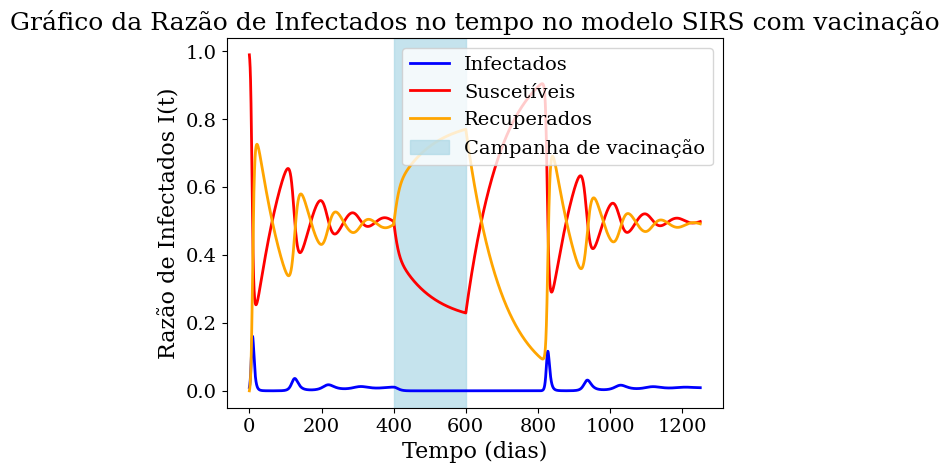

In [11]:
sirxt(arquivo_h5['sim_0']) 

Mapa de Calor: Probabilidade de Extinção em função de R0 e do número de vacinas para um conjunto fixo dos demais parâmetros

In [52]:
def r0xvac_num(arquivo, nome_arquivo_saida=None):
    dados = []
    for grupo_simulacao in arquivo.values():
        # 1. Extrai os dados e parâmetros dos datasets
        params = grupo_simulacao.attrs
        N = params.get('N', 'N/A')
        r0 = params.get('r0', 'N/A')
        prob_ext = params.get('prob_ext', 'N/A')
        vac_num = params.get('vac_num', 'N/A')
        # 2. Armazena os dados em uma lista de dicionários
        dados_simulacao = {
            'N' : N,
            'Basic Reprodution Number': r0,
            'Vaccines Number (Normalized)': vac_num,
            'Extinction Probability': prob_ext
        }
        dados.append(dados_simulacao)
    dados = pd.DataFrame(dados)

    x = dados['Basic Reprodution Number']
    y = dados['Vaccines Number (Normalized)']
    z = dados['Extinction Probability']
    x_unique = np.sort(x.unique())
    y_unique = np.sort(y.unique())
    # Criando uma matriz de zeros com dimensões baseadas em x e y
    Z = np.zeros((len(y_unique), len(x_unique)))
    # Preencher a matriz Z com os valores correspondentes
    for i, xi in enumerate(x_unique):
        for j, yj in enumerate(y_unique):
            mask = (x == xi) & (y == yj)
            if mask.any():
                Z[j, i] = dados.loc[mask, 'Extinction Probability'].mean()
    print(Z)
                # Criar o gráfico de mapa de calor
    plt.figure(figsize=(10, 6))
    plt.imshow(Z, aspect='auto', origin='lower', cmap='hot',
            extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)

    # Cor da barra de cor
    cbar = plt.colorbar(label="Extinction Probability")
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
    cbar.set_label("Extinction Probability", color='black')

    # Eixos e título em preto
    plt.xlabel('Basic Reprodution Number', color='black')
    plt.ylabel('Vaccines Number (Normalized)', color='black')
    plt.title("Extinction Probability: R0 x Vaccines Number", color='black')

    # Ticks em preto
    plt.tick_params(axis='both', colors='black')
    plt.grid(False)
    plt.show()

[[0.         0.         0.        ]
 [0.99999987 1.         1.        ]]


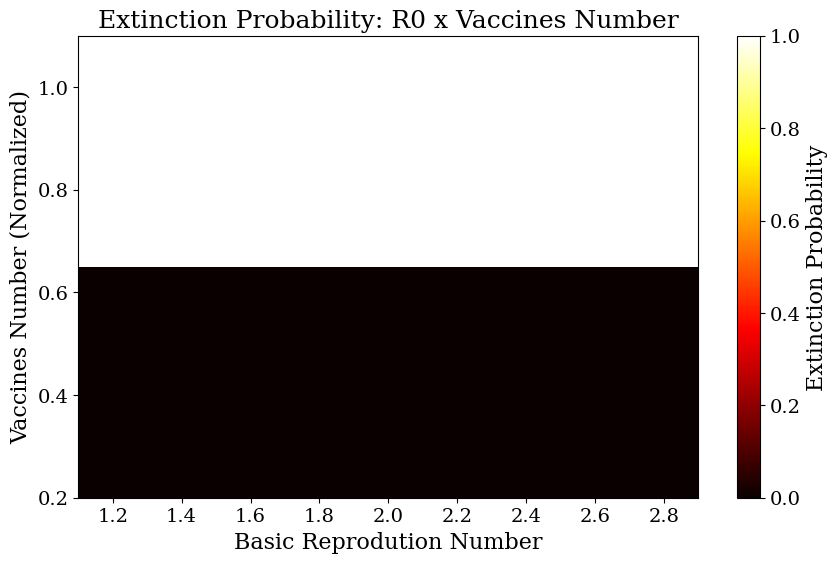

In [51]:
arquivo_h5 = h5py.File('Mapas de Calor - N = 10000.0.h5', 'r')
r0xvac_num(arquivo_h5)
arquivo_h5.close()

Creating a pannel with 4 different heat maps of R0 x Vaccines Number:

In [87]:
def r0xvac_num_4(arquivos, nome_arquivo_saida=None):
    plt.figure(figsize=(30, 15))
    fig, axs = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
    axs = axs.flatten()
    for ax, arquivo in zip(axs, arquivos):
        dados = []
        for grupo_simulacao in arquivo.values():
            # 1. Extrai os dados e parâmetros dos datasets
            params = grupo_simulacao.attrs
            N = params.get('n', 'N/A')
            r0 = params.get('r0', 'N/A')
            prob_ext = params.get('prob_ext', 'N/A')
            vac_num = params.get('vac_num', 'N/A')
            # 2. Armazena os dados em uma lista de dicionários
            dados_simulacao = {
                'N' : N,
                'Basic Reprodution Number': r0,
                'Vaccines Number (Normalized)': vac_num,
                'Extinction Probability': prob_ext
            }
            dados.append(dados_simulacao)
        dados = pd.DataFrame(dados)

        x = dados['Basic Reprodution Number']
        y = dados['Vaccines Number (Normalized)']
        z = dados['Extinction Probability']
        N_val = dados['N'].iloc[1]  # Obtém o valor de N da primeira linha
        x_unique = np.sort(x.unique())
        y_unique = np.sort(y.unique())
        # Criando uma matriz de zeros com dimensões baseadas em x e y
        Z = np.zeros((len(y_unique), len(x_unique)))
        # Preencher a matriz Z com os valores correspondentes
        for i, xi in enumerate(x_unique):
            for j, yj in enumerate(y_unique):
                mask = (x == xi) & (y == yj)
                if mask.any():
                    Z[j, i] = dados.loc[mask, 'Extinction Probability'].mean()
        print(Z)
        # Criar o gráfico de mapa de calor

        im = ax.imshow(Z, aspect='auto', origin='lower', cmap='hot',
                       extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)

        ax.set_xlabel(r"$R_o$", color='black', fontsize=16)
        ax.set_ylabel('V', color='black', fontsize=16)
        ax.set_title(f'N = {N_val}', fontsize=18)
        
        # Ticks e grid específicos para este subplot
        ax.tick_params(axis='both', colors='black', labelsize=15)
        ax.grid(False)

    # Adicionando a barra de cor comum para todos os subplots:
    cbar = fig.colorbar(im, ax=axs.tolist(), label="Extinction Probability", shrink=0.8)
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black', fontsize=16)
    cbar.set_label("Extinction Probability", color='black', fontsize=18)

    # Adiciona um título geral para a figura usando 'fig.suptitle'
    fig.suptitle(r"$\text{Extinction Probability: } R_0 \times \text{Vaccines Number}$", color='black', fontsize=22)
    plt.show()

In [88]:
arquivos = [h5py.File('Mapas de Calor - N = 10000.0.h5', 'r'), h5py.File('Mapas de Calor - N = 100000.0.h5', 'r'), h5py.File('Mapas de Calor - N = 1000000.0.h5', 'r'), h5py.File('Mapas de Calor - N = 10000000.0.h5', 'r')]
r0xvac_num_4(arquivos)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.07956233 0.         0.         ... 1.         1.         1.        ]
 [0.18613157 0.         0.         ... 1.         1.         1.        ]
 ...
 [1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]]
[[0.         0.         1.        ]
 [0.99999987 1.         1.        ]]
[[0.         0.         0.        ]
 [0.99999987 0.         1.        ]]
[[0.         0.         0.        ]
 [0.99999987 0.         1.        ]]


<Figure size 3000x1500 with 0 Axes>

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpfyyj5kr3 236e77822d811e08fa76f34911316a3365a1c953d49790ceb840d522dd81e463.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./236e77822d811e08fa76f34911316a3365a1c953d49790ceb840d522dd81e463.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)

! LaTeX Error: File `type1ec.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         

<Figure size 1500x1000 with 5 Axes>

Plotting the same heat map, however now differentiating the cases where the simulation stopped because of the lack of susceptible from the rest of the simulations.

In [97]:
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches


def r0xvac_num_4_s(arquivos, nome_arquivo_saida=None):
    plt.figure(figsize=(30, 15))
    fig, axs = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
    axs = axs.flatten()
    for ax, arquivo in zip(axs, arquivos):
        dados = []
        for grupo_simulacao in arquivo.values():
            # 1. Extrai os dados e parâmetros dos datasets
            params = grupo_simulacao.attrs
            N = params.get('n', 'N/A')
            r0 = params.get('r0', 'N/A')
            prob_ext = params.get('prob_ext', 'N/A')
            vac_num = params.get('vac_num', 'N/A')
            motivo_parada = params.get('motivo_parada', 'N/A')
            # Agora determinamos que a probabilidade de extinção no caso que a simulação parou por S < 1/n como sendo 2, apneas 
            # para tratar este caso separadamente, lhe conferindo uma cor distinta.
            if motivo_parada == 'S Mínimo':
                prob_ext = 2
            # 2. Armazena os dados em uma lista de dicionários
            dados_simulacao = {
                'N' : N,
                'Basic Reprodution Number': r0,
                'Vaccines Number (Normalized)': vac_num,
                'Extinction Probability': prob_ext
            }
            dados.append(dados_simulacao)
        dados = pd.DataFrame(dados)
        x = dados['Basic Reprodution Number']
        y = dados['Vaccines Number (Normalized)']
        z = dados['Extinction Probability']
        N_val = dados['N'].iloc[1]  # Obtém o valor de N da primeira linha
        x_unique = np.sort(x.unique())
        y_unique = np.sort(y.unique())
        # Criando uma matriz de zeros com dimensões baseadas em x e y
        Z = np.zeros((len(y_unique), len(x_unique)))
        # Preencher a matriz Z com os valores correspondentes
        for i, xi in enumerate(x_unique):
            for j, yj in enumerate(y_unique):
                mask = (x == xi) & (y == yj)
                if mask.any():
                    Z[j, i] = dados.loc[mask, 'Extinction Probability']
        print(Z)
        # Criar o gráfico de mapa de calor
        gradiente = plt.cm.hot(np.linspace(0, 1, 256))  # Gradiente hot
        cor_unica = np.array([[1, 0.678, 0.882, 1]])
        cores_personalizadas = np.vstack((gradiente, cor_unica))
        cmap_personalizado = ListedColormap(cores_personalizadas)
        limites = [0,1,2,3]
        norm = BoundaryNorm(limites, cmap_personalizado.N)
        im = ax.imshow(Z, aspect='auto', origin='lower', cmap=cmap_personalizado,
                       extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)

        ax.set_xlabel(r"$R_o$", color='black', fontsize=16)
        ax.set_ylabel('V', color='black', fontsize=16)
        ax.set_title(f'N = {N_val}', fontsize=18)
        s_minimo_patch = mpatches.Patch(color='pink', label=r"$S < \frac{1}{N}$")
        ax.legend(handles=[s_minimo_patch], loc='upper right')
        
        # Ticks e grid específicos para este subplot
        ax.tick_params(axis='both', colors='black', labelsize=15)
        ax.grid(False)

    # Adicionando a barra de cor comum para todos os subplots:
    cbar = fig.colorbar(im, ax=axs.tolist(), label="Extinction Probability", shrink=0.8)
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black', fontsize=16)
    cbar.set_label("Extinction Probability", color='black', fontsize=18)

    # Adiciona um título geral para a figura usando 'fig.suptitle'
    fig.suptitle(r"Extinction Probability: $R_o \times$ Vaccines Number", color='black', fontsize=22)
    plt.show()

In [100]:
arquivos = [h5py.File('Mapas de Calor - N = 10000.0.h5', 'r'), h5py.File('Mapas de Calor - N = 100000.0.h5', 'r'), h5py.File('Mapas de Calor - N = 1000000.0.h5', 'r'), h5py.File('Mapas de Calor - N = 10000000.0.h5', 'r')]
r0xvac_num_4_s(arquivos)

/tmp/ipykernel_6040/1161682827.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Z[j, i] = dados.loc[mask, 'Extinction Probability']


[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.07956233 0.         0.         ... 2.         2.         2.        ]
 [0.18613157 0.         0.         ... 2.         2.         2.        ]
 ...
 [1.         1.         1.         ... 2.         2.         2.        ]
 [1.         1.         1.         ... 2.         2.         2.        ]
 [2.         2.         2.         ... 2.         2.         2.        ]]
[[0.         0.         2.        ]
 [0.99999987 2.         2.        ]]
[[0.         0.         0.        ]
 [0.99999987 0.         2.        ]]
[[0.         0.         0.        ]
 [0.99999987 0.         2.        ]]


<Figure size 3000x1500 with 0 Axes>

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp2w_288dj bd29e5788d038a22dfc8e46a8a403521e47c2c280f726258538435d092607b58.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./bd29e5788d038a22dfc8e46a8a403521e47c2c280f726258538435d092607b58.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)

! LaTeX Error: File `type1ec.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         

<Figure size 1500x1000 with 5 Axes>

Mapa de calor: Probabilidade de extinção para cada tempo de início da campanha de vacinação e de R0:

In [58]:
def t0xr0map(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupo_simulacao = f[key]
            params = grupo_simulacao.attrs
            r0 = params.get('r0', np.nan)
            t0 = params.get('t0', np.nan)
            prob_ext = params.get('prob_ext', np.nan)
            a = params.get('a', np.nan)
            vac_num = params.get('vac_num', np.nan)
            dados_simulacao = {
                'Basic Reprodution Number': r0,
                'Start Time of Vaccination Campaign': t0,
                'Extinction Probability': prob_ext,
                'Vaccination Rate': a,
                'Vaccines Number (Normalized)': vac_num
            }
            dados.append(dados_simulacao)
            df = pd.DataFrame(dados)

    x = df['Basic Reprodution Number']
    y = df['Start Time of Vaccination Campaign']
    z = df['Extinction Probability']
    x_unique = np.sort(x.unique())
    y_unique = np.sort(y.unique())
    # Criando uma matriz de zeros com dimensões baseadas em x e y
    Z = np.zeros((len(y_unique), len(x_unique)))
    # Preencher a matriz Z com os valores correspondentes
    for i, xi in enumerate(x_unique):
        for j, yj in enumerate(y_unique):
            mask = (x == xi) & (y == yj)
            if mask.any():
                Z[j, i] = df.loc[mask, 'Extinction Probability'].mean()
    print(Z)
                # Criar o gráfico de mapa de calor
    plt.figure(figsize=(10, 6))
    plt.imshow(Z, aspect='auto', origin='lower', cmap='hot',
            extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)

    # Cor da barra de cor
    cbar = plt.colorbar(label="Extinction Probability")
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
    cbar.set_label("Extinction Probability", color='black')

    # Eixos e título em preto
    plt.xlabel('Basic Reprodution Number', color='black')
    plt.ylabel('Start Time of Vaccination Campaign', color='black')
    plt.title("Extinction Probability: Basic Reprodution Number x Start Time of Vaccination Campaign", color='black')

    # Ticks em preto
    plt.tick_params(axis='both', colors='black')
    plt.grid(False)
    plt.show()

[[0.98972167 0.95711761 0.84138405 ... 0.         0.         0.        ]
 [0.98930725 0.955265   0.8349482  ... 0.         0.         0.        ]
 [0.98888182 0.95337728 0.82853729 ... 0.         0.         0.        ]
 ...
 [0.98472861 0.9739307  0.95515027 ... 0.         0.         0.        ]
 [0.9850408  0.97441622 0.955545   ... 0.         0.         0.        ]
 [0.9853435  0.97487351 0.95589055 ... 0.         0.         0.        ]]


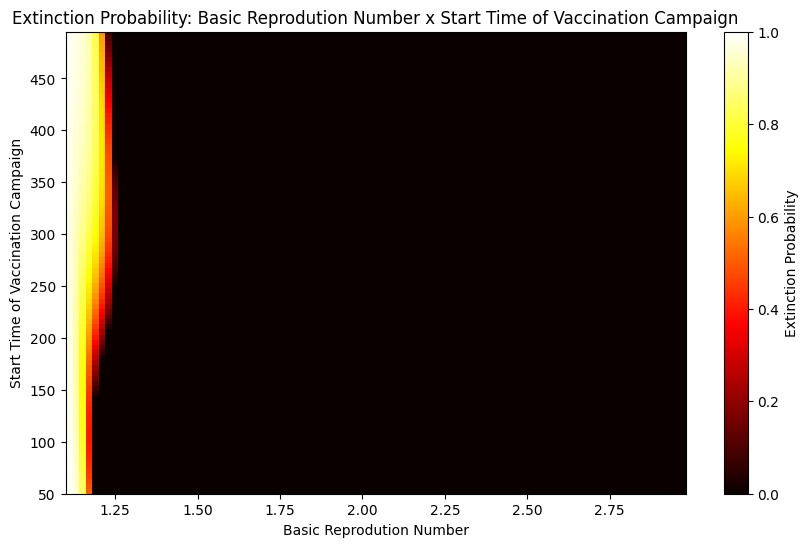

In [59]:
arquivo_h5 = h5py.File('Simulações t0 x r0.h5', 'r')
t0xr0map(arquivo_h5)

Gráfico do tempo ideal de aplicação da campanha de vacinação para cada valor de R0:
Neste gráfico busca-se encontrar para cada valor de R0 o momento do de início da camapanha que maximiza a probabilidade de extinção.
É interessante comparar tal gráfico com um gráfico do momento do pico x R0 no modelo SIRS sem vacinação para os mesmo parâmetros.

In [60]:
def t0xr0(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupo_simulacao = f[key]
            params = grupo_simulacao.attrs
            r0 = params.get('r0', np.nan)
            t0 = params.get('t0', np.nan)
            prob_ext = params.get('prob_ext', np.nan)
            a = params.get('a', np.nan)
            vac_num = params.get('vac_num', np.nan)
            dados_simulacao = {
                'r0': r0,
                't0': t0,
                'prob_ext': prob_ext,
                'a': a,
                'vac_num': vac_num
            }
            dados.append(dados_simulacao)
        df_completo = pd.DataFrame(dados)
        idx_max_prob = df_completo.groupby('r0')['prob_ext'].idxmax()
        df_otimo = df_completo.loc[idx_max_prob]
    plt.figure(figsize=(10, 6))

    plt.scatter(df_otimo['r0'], df_otimo['t0'], c=df_otimo['prob_ext'], cmap='viridis', s=40, edgecolor='black', vmin=0, vmax=1)
    cbar = plt.colorbar()
    cbar.set_label('Probabilidade de Extinção Máxima')
    plt.xlabel('Número de Reprodução Básico (R0)')
    plt.ylabel('t0 Ótimo (início da camapanha)')
    plt.title('Data de início da campanha que maximiza a Probabilidade de Extinção para cada R0')
    plt.grid()
    plt.show()

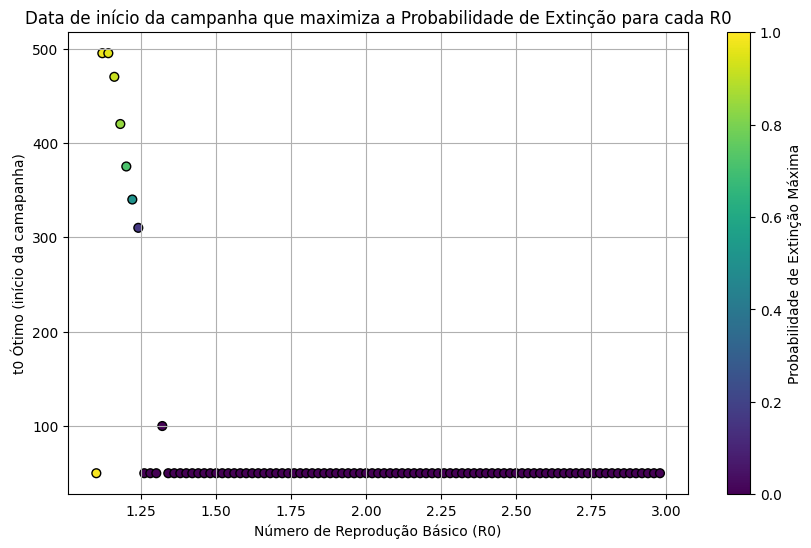

In [61]:
arquivo_h5 = h5py.File('Simulações t0 x r0.h5', 'r')
t0xr0(arquivo_h5)

Gráfico do momento do pico x R0 no modelo SIRS sem vacinação:

In [62]:
def picoxr0(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupo_simulacao = f[key]
            params = grupo_simulacao.attrs
            tempo = grupo_simulacao['tempo'][:]
            I = grupo_simulacao['I'][:]
            indice_do_pico = np.argmax(I)
            t_pico = tempo[indice_do_pico]
            r0 = params.get('r0', 'N/A')
            dados = []
            dados_simulacao = {
                'r0': r0,
                't_pico': t_pico
            }
            dados.append(dados_simulacao)
            dados = pd.DataFrame(dados)
    plt.figure(figsize=(10, 6))
    plt.scatter(dados['r0'], dados['t_pico'], color='blue', edgecolor='black', s=100)
    plt.xlabel('Número de Reprodução Básico (R0)')
    plt.ylabel('Tempo até o Pico de Infectados (dias)')
    plt.title('Tempo até o Pico de Infectados em função do R0')
    plt.grid()
    plt.show()

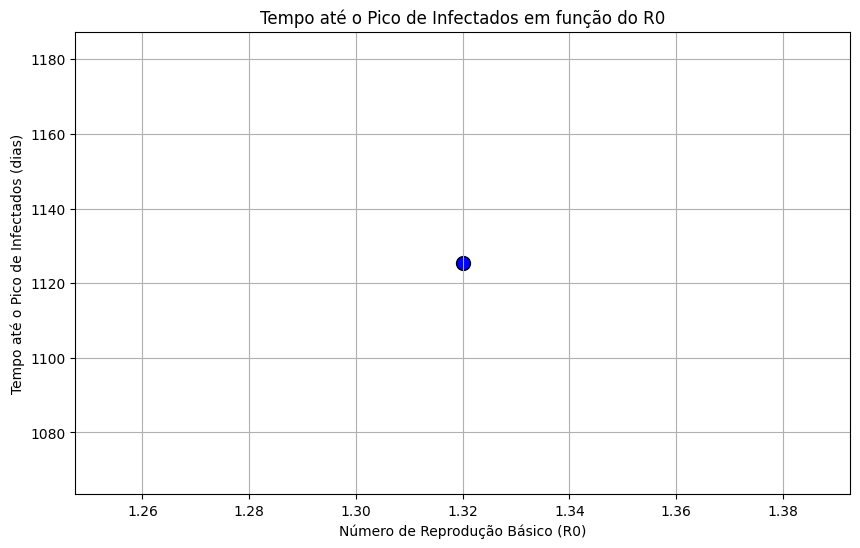

In [63]:
arquivo_h5 = h5py.File('Simulações t0 x r0.h5', 'r')
picoxr0(arquivo_h5)

Probabilidade de extinção x t0:

In [ ]:
def probextxt0(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupos_r0 = []
            grupo_simulacao = f[key]
            if np.isclose(grupo_simulacao.attrs.get('r0', np.nan), 1.2):
                grupos_r0.append(grupo_simulacao)
                params = grupo_simulacao.attrs
                t0 = params.get('t0', np.nan)
                prob_ext = params.get('prob_ext', np.nan)
                r0 = params.get('r0', np.nan)
                dados_simulacao = {
                    't0': t0,
                    'prob_ext': prob_ext,
                    'r0' : r0
                }
                dados.append(dados_simulacao)
        df = pd.DataFrame(dados)
    print(df.loc[df['prob_ext'].idxmax(), 't0'])
    plt.figure(figsize=(12, 6))

    plt.scatter(df['t0'], df['prob_ext'], label = 'Probabilidade de Extinção', color='black', edgecolor='black', s=5)
    plt.xlabel('Momento de início da campanha (t0)')
    plt.ylim(-0.1, 1.1)
    plt.ylabel('Probabilidade de Extinção')
    plt.title('Probabilidade de Extinção x Momento de início da campanha')
    plt.grid()
    plt.show()

376


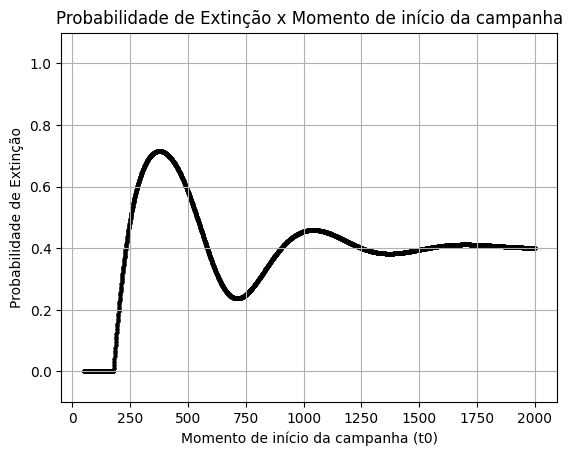

In [ ]:
arquivo_h5 = h5py.File('Simulações prob_ext x t0 r0 =1.2.h5', 'r')
probextxt0(arquivo_h5)

Gráfico de comparação entre prob_ext x t0 e Ixt no caso sem vacinação (ambos normalizados):

In [27]:
def comparacao(arquivo_prob_ext, arquivo_Ixt, nome_arquivo_saida=None):
    # Prob_ext x t0
    dados_prob = []
    with arquivo_prob_ext as f:
        for key in f.keys():
            grupos_r0 = []
            simulacao = f[key]
            if np.isclose(simulacao.attrs.get('r0', np.nan), 1.2):
                params = simulacao.attrs
                dados_simulacao = {
                    't0': params.get('t0', np.nan),
                    'prob_ext': params.get('prob_ext', np.nan),
                    'r0' : params.get('r0', np.nan)
                }
                dados_prob.append(dados_simulacao)
        df = pd.DataFrame(dados_prob)
    print('Tempo do pico da probabilidade de extinção', df.loc[df['prob_ext'].idxmax(), 't0'])
    prob_ext_max = df['prob_ext'].max()
    print(f'Maximum Extinction Probability: {prob_ext_max}')
    # Ixt
    sim_base = arquivo_Ixt['sim_0'] 
    tempo = sim_base['tempo'][:]
    I = sim_base['I'][:]
    I_max = np.max(I)
    params = sim_base.attrs
    r0 = params.get('r0', 'N/A')
    t_pico = tempo[np.argmax(I)] if np.any(I) else None
    print(f'\nParâmetros da simulação base (sem vacinação): r0 = {r0}, t_pico = {t_pico}')
    plt.figure(figsize=(12, 6))
    plt.plot(tempo, I/I_max, label='Infectados', color='blue')
    plt.scatter(df['t0'], df['prob_ext']/prob_ext_max, label = 'Probabilidade de Extinção', color='black', edgecolor='black', s=7)
    plt.ylim(-0.1, 1.1)
    plt.xlabel('Tempo (dias)')
    plt.ylabel('Razão Normalizada')
    plt.legend(loc='upper right')
    plt.title('Probabilidade de Extinção vs. Momento de Início da Campanha')
    plt.grid()
    plt.show()

Tempo do pico da probabilidade de extinção 376.5
Maximum Extinction Probability: 0.7156356436191744

Parâmetros da simulação base (sem vacinação): r0 = 1.2, t_pico = 342.1171058552928


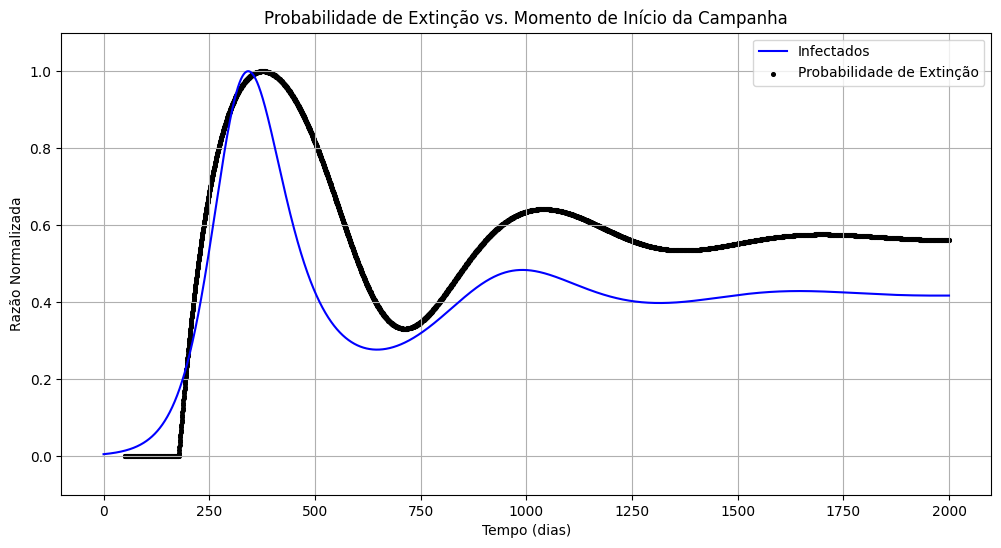

In [38]:
arquivo_prob_ext = h5py.File('Simulações prob_ext x t0 r0 =1.2.h5', 'r')
arquivo_Ixt = h5py.File('Simulações r0 =1.2 sem vacinacao.h5', 'r')

comparacao(arquivo_prob_ext, arquivo_Ixt)

arquivo_prob_ext.close()
arquivo_Ixt.close()

In [ ]:
def analisar_alinhamento_minimizando_distancia(arquivo_prob_ext, arquivo_Ixt, max_deslocamento=500):
    """
    Função que alinha duas curvas implementando o seguinte algoritmo:
    minimiza a soma das distâncias temporais ao quadrado entre picos e vales correspondentes.
    """
    dados_prob = []
    for key in arquivo_prob_ext.keys():
        simulacao = arquivo_prob_ext[key]
        if np.isclose(simulacao.attrs.get('r0', np.nan), 1.2):
            params = simulacao.attrs
            dados_simulacao = {'t0': params.get('t0', np.nan), 'prob_ext': params.get('prob_ext', np.nan)}
            dados_prob.append(dados_simulacao)
    
    df = pd.DataFrame(dados_prob)
    if df.empty: return
        
    df_sorted = df.sort_values(by='t0').reset_index(drop=True)
    prob_ext_ordenado = df_sorted['prob_ext']
    tempo_prob_ext_ordenado = df_sorted['t0']
    
    sim_base = arquivo_Ixt['sim_0'] 
    tempo_Ixt = sim_base['tempo'][:]
    I = sim_base['I'][:]

    # Interpolando prob_ext para os mesmos tempos de Ixt
    prob_ext_interpolado = np.interp(tempo_Ixt, tempo_prob_ext_ordenado, prob_ext_ordenado)

    # Normalização das curvas
    I_norm = (I - np.min(I)) / (np.max(I) - np.min(I))
    prob_ext_norm = (prob_ext_interpolado - np.min(prob_ext_interpolado)) / (np.max(prob_ext_interpolado) - np.min(prob_ext_interpolado))

    # Encontrar picos e vales usando scipy.signal.find_peaks
    indices_picos_I, _ = find_peaks(I_norm, height=0.3, distance=150)
    indices_vales_I, _ = find_peaks(1 - I_norm, height=0.3, distance=150)
    indices_picos_prob, _ = find_peaks(prob_ext_norm, height=0.3, distance=150)
    indices_vales_prob, _ = find_peaks(1 - prob_ext_norm, height=0.3, distance=150)

    indices_ancoragem_I = np.sort(np.concatenate([indices_picos_I, indices_vales_I]))
    indices_ancoragem_prob = np.sort(np.concatenate([indices_picos_prob, indices_vales_prob]))
    
    n_ancoragens = min(len(indices_ancoragem_I), len(indices_ancoragem_prob))
    if n_ancoragens < 1:
        print("ERRO: Não foram encontrados picos/vales suficientes.")
        return
        
    indices_ancoragem_I = indices_ancoragem_I[:n_ancoragens]
    indices_ancoragem_prob = indices_ancoragem_prob[:n_ancoragens]

    tempos_ancoragem_I = tempo_Ixt[indices_ancoragem_I]
    tempos_ancoragem_prob = tempo_Ixt[indices_ancoragem_prob]

    # Loop para Encontrar o Deslocamento que Minimiza o a diferença entre extremos
    passo_de_tempo = tempo_Ixt[1] - tempo_Ixt[0] if len(tempo_Ixt) > 1 else 1
    deslocamentos_passos = np.arange(-max_deslocamento, max_deslocamento + 1)
    deslocamentos_tempo = deslocamentos_passos * passo_de_tempo
    
    custos = []
    for d in deslocamentos_tempo:
        # Calcula a diferença de tempo para cada par de picos/vales, considerando o deslocamento 'd'
        diferencas_temporais = tempos_ancoragem_I - (tempos_ancoragem_prob + d)
        # O custo é a soma das diferenças ao quadrado (Soma dos Erros Quadráticos)
        custo_total = np.sum(diferencas_temporais**2)
        custos.append(custo_total)

    # --- 4. Encontrar o Melhor Deslocamento ---
    min_custo_idx = np.argmin(custos)
    melhor_deslocamento = deslocamentos_tempo[min_custo_idx]
    min_custo = custos[min_custo_idx]

    print("\n --- Resultado da Análise por Minimização de Distância entre extremos ---")
    print(f"O deslocamento que minimiza a distância entre os picos/vales é: {melhor_deslocamento:.4f}")
    print(f"O custo (soma das distâncias ao quadrado) mínimo é: {min_custo:.4f}")

    # --- Cálculo Direto usando a média das diferenças entre extremos correspondentes ---
    diferencas_de_tempo = tempos_ancoragem_I - tempos_ancoragem_prob
    deslocamento_analitico = np.mean(diferencas_de_tempo)
    print(f"Cálculo direto (média das diferenças): {deslocamento_analitico:.4f} (deve ser quase idêntico ao do loop)")
    
    # Gráfico 1: Distância entre extremos vs. Deslocamento
    plt.figure(figsize=(12, 6))
    plt.plot(deslocamentos_tempo, custos, label = 'Soma das Distâncias ao Quadrado', color='blue')
    plt.axvline(x=melhor_deslocamento, color='r', linestyle='--', label=f'Deslocamento Ótimo ({melhor_deslocamento:.2f})')
    plt.title('Soma das distâncias ao quadrado x Deslocamento')
    plt.xlabel('Deslocamento no tempo (t)')
    plt.ylabel('Soma das Distâncias ao Quadrado')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráfico 2: Gráfico de comparação das curvas alinhadas
    plt.figure(figsize=(12, 6))
    plt.plot(tempo_Ixt, I_norm, label='Curva de Infectados', color='blue', linewidth=2)
    plt.plot(tempo_Ixt, prob_ext_norm, label='Prob. Extinção (Original)', color='gray', linestyle=':', linewidth=2)
    tempo_prob_deslocado = tempo_Ixt + melhor_deslocamento
    plt.plot(tempo_prob_deslocado, prob_ext_norm, label=f'Prob. Extinção (Alinhada por Mínimos Quadrados)', color='red', linestyle='--', linewidth=2)
    plt.title('Curvas Alinhadas: Infectados e Probabilidade de Extinção')
    plt.xlabel('Tempo (t)')
    plt.ylabel('Valor Normalizado')
    plt.legend()
    plt.grid(True)
    plt.show()

Iniciando a análise de alinhamento por minimização de distância...

 --- Resultado da Análise por Minimização de Distância entre extremos ---
O deslocamento que minimiza a distância entre os picos/vales é: -51.7026
O custo (soma das distâncias ao quadrado) mínimo é: 511.7112
Cálculo direto (média das diferenças): -51.7026 (deve ser quase idêntico ao do loop)


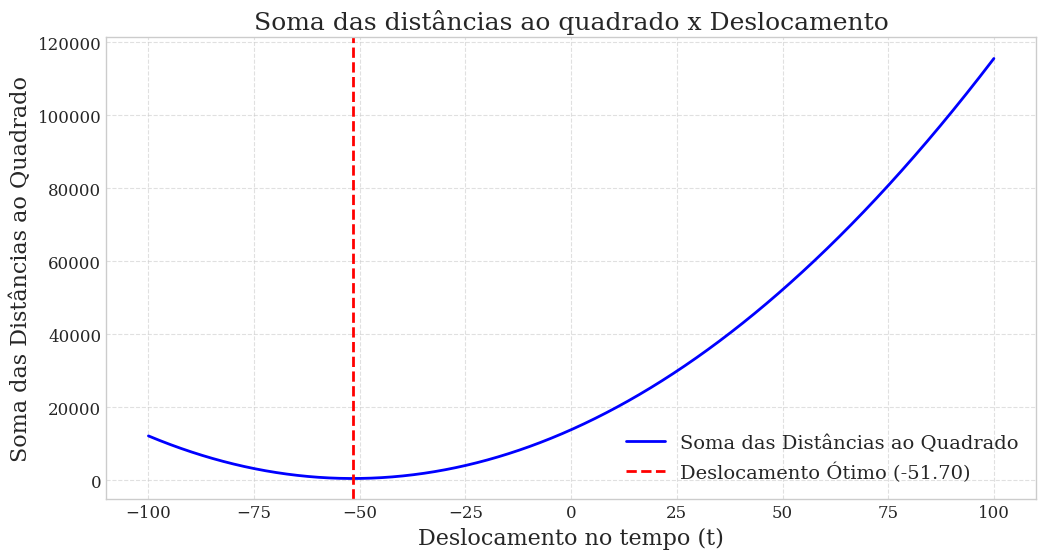

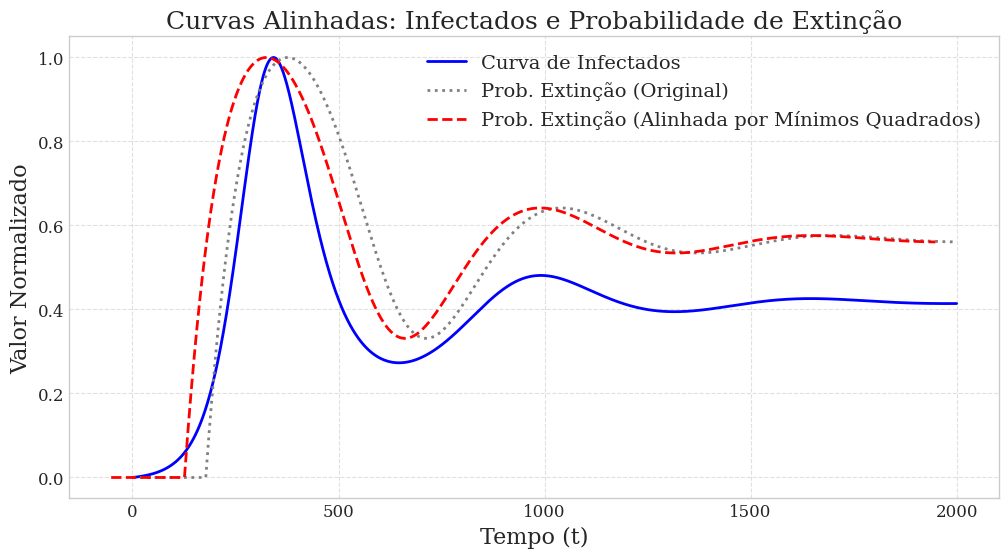

In [22]:
nome_arquivo_prob_ext = 'Simulações prob_ext x t0 r0 =1.2.h5'
nome_arquivo_Ixt = 'Simulações r0 =1.2 sem vacinacao.h5'

print("Iniciando a análise de alinhamento por minimização de distância...")

try:
    with h5py.File(nome_arquivo_prob_ext, 'r') as arquivo_prob_ext, \
            h5py.File(nome_arquivo_Ixt, 'r') as arquivo_Ixt:
        analisar_alinhamento_minimizando_distancia(arquivo_prob_ext, arquivo_Ixt, max_deslocamento=1000)
except Exception as e:
    print(f"\nOcorreu um erro inesperado: {e}")

Gráfico da Probabilidade de Extinção para diferentes durações da campanha e diferentes valores de t0: 

In [9]:
def duracaoxt0(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupo_simulacao = f[key]
            params = grupo_simulacao.attrs
            t0 = params.get('t0', np.nan)
            prob_ext = params.get('prob_ext', np.nan)
            a = params.get('a', np.nan)
            dados_simulacao = {
                'Start Time of Vaccination Campaign': t0,
                'Extinction Probability': prob_ext,
                'Vaccination Rate': a,
                'Duration of Vaccination Campaign': params.get('vac_num', np.nan)/a if a != 0 else np.nan
            }
            dados.append(dados_simulacao)
        df = pd.DataFrame(dados)

    x = df['Start Time of Vaccination Campaign']
    y = df['Duration of Vaccination Campaign']
    z = df['Extinction Probability']
    x_unique = np.sort(x.unique())
    y_unique = np.sort(y.unique())
    # Criando uma matriz de zeros com dimensões baseadas em x e y
    Z = np.zeros((len(y_unique), len(x_unique)))
    # Preencher a matriz Z com os valores correspondentes
    for i, xi in enumerate(x_unique):
        for j, yj in enumerate(y_unique):
            mask = (x == xi) & (y == yj)
            if mask.any():
                Z[j, i] = df.loc[mask, 'Extinction Probability'].mean()
    print(Z)
                # Criar o gráfico de mapa de calor
    plt.figure(figsize=(10, 6))
    X, Y = np.meshgrid(x_unique, y_unique)
    c = plt.pcolormesh(X, Y, Z, cmap='viridis_r', shading='nearest', vmin=0, vmax=1)
    
    # Adiciona a barra de cores
    colorbar_label = 'Probabilidade de extinção'
    plt.colorbar(c, label=colorbar_label, fraction=0.046, pad=0.04)

    # 3. CORREÇÃO DE SINTAXE: Usar plt.xlabel e plt.ylabel
    plt.xlabel('Início da campanha (dias)')
    plt.ylabel('Duração da campanha (dias)')
    plt.title('Impacto da Vacinação na Extinção da Doença')

    # 4. USO DO PARÂMETRO: Salvar o arquivo com o nome fornecido
    plt.savefig(nome_arquivo_saida, dpi=300, format='jpg', bbox_inches='tight')
    plt.show()

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Ocorreu um erro inesperado: 'NoneType' object has no attribute 'write'


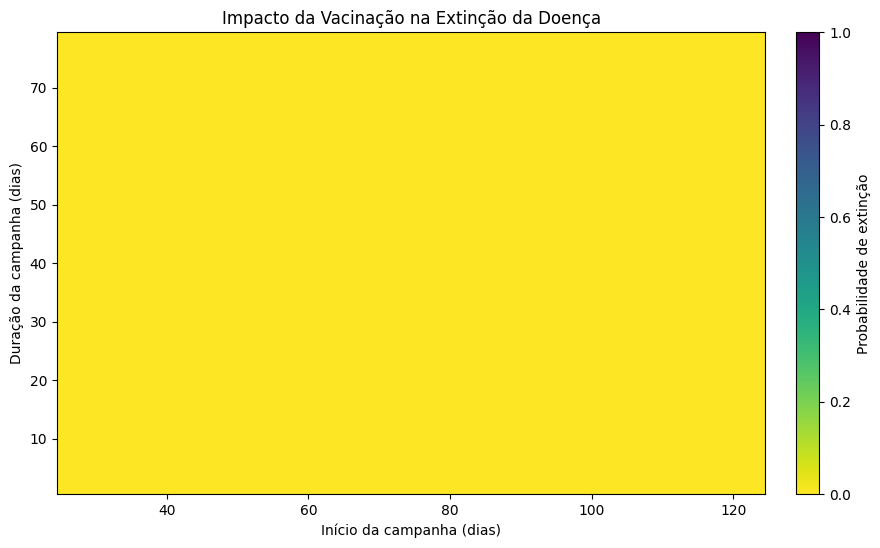

In [12]:
nome_arquivo_duracao_t0 = 'Grafico Pablo.h5'

try:
    with h5py.File(nome_arquivo_duracao_t0, 'r') as arquivo_duracao_t0:
        duracaoxt0(arquivo_duracao_t0)
except Exception as e:
    print(f"\nOcorreu um erro inesperado: {e}")